# Reproducible ideal baseline and CW batches

This notebook keeps one immutable post-`make_ideal` partim baseline. Every monochromatic CW batch is injected into an independent deep copy of that baseline and written to its own checksummed directory. Existing datasets are validated and reused; they are never silently overwritten.

In [1]:
import hashlib
import json
import platform
import sys
from copy import deepcopy
from datetime import datetime, timezone
from importlib.metadata import PackageNotFoundError, version
from pathlib import Path

import astropy.units as u
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
from pint import toa as pint_toa
from pint.logging import setup as setup_pint_logging
from pint.models import get_model
from pint.residuals import Residuals
from pta_replicator.deterministic import add_cgw
from pta_replicator.simulate import SimulatedPulsar, make_ideal, simulate_pulsar

setup_pint_logging(level="WARNING")

libstempo not installed. PINT or libstempo are required to use par and tim files.


1

## Physical and batch parameters

Add future monochromatic injections to `CW_BATCHES`. Labels must be unique. The physical model below is unchanged from `notebook.ipynb`.

In [2]:
obstime = np.arange(53000, 56650, 14)
N_PSR = 25

T_seconds = (obstime[-1] - obstime[0]) * 86400.0
f = 1.0 / T_seconds

source_ra = np.deg2rad(2.0)
source_dec = np.deg2rad(0.4)
gwphi = source_ra
gwtheta = np.pi / 2.0 - source_dec

CW_BATCHES = [
    {"label": "k5p5", "k0": 5, "delta": 0.5},
]
ANALYSIS_BATCH = "k5p5"

CW_PARAMETERS = {
    "mc_solar_masses": 1.0e9,
    "dist_mpc": 100.0,
    "phase0_rad": 0.0,
    "psi_rad": 0.0,
    "inc_rad": float(np.pi / 3.0),
    "psrTerm": False,
    "evolve": False,
    "phase_approx": False,
    "tref_seconds": float(obstime[0] * 86400.0),
    "signal_name": "cw",
}

assert len({batch["label"] for batch in CW_BATCHES}) == len(CW_BATCHES)
assert ANALYSIS_BATCH in {batch["label"] for batch in CW_BATCHES}

In [3]:
template_par = Path("data/JPSR00.par")
dataset_root = Path("cw_batch_data")
model_par_dir = dataset_root / "model_par" / "baseline_v1"
ideal_dir = dataset_root / "ideal" / "baseline_v1"
cw_root = dataset_root / "cw"
legacy_source_dir = Path("data/cw_partim")
legacy_archive_dir = dataset_root / "archive" / "cw_partim.pre-repair-20260722T015354"

psr_names = [f"J{i:02d}" for i in range(N_PSR)]

## Checksummed dataset helpers

In [4]:
def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def partim_hashes(directory):
    directory = Path(directory)
    paths = sorted(directory.glob("*.par")) + sorted(directory.glob("*.tim"))
    return {path.name: sha256_file(path) for path in paths}


def expected_partim_filenames(names):
    return sorted([f"{name}.par" for name in names] + [f"{name}.tim" for name in names])


def residual_stats(psrs):
    residuals_ns = np.concatenate([
        np.asarray(psr.residuals.time_resids.to_value(u.ns), dtype=np.longdouble)
        for psr in psrs
    ])
    return {
        "sample_count": int(residuals_ns.size),
        "rms_ns": float(np.sqrt(np.mean(residuals_ns**2))),
        "max_abs_ns": float(np.max(np.abs(residuals_ns))),
    }


def installed_version(distribution):
    try:
        return version(distribution)
    except PackageNotFoundError:
        return "unknown"


SOFTWARE = {
    "python": platform.python_version(),
    "platform": platform.platform(),
    "numpy": installed_version("numpy"),
    "astropy": installed_version("astropy"),
    "pint-pulsar": installed_version("pint-pulsar"),
    "pta-replicator": installed_version("pta-replicator"),
}


def validate_dataset(directory, dataset_type, label, config, names):
    directory = Path(directory)
    manifest_path = directory / "manifest.json"
    if not manifest_path.is_file():
        raise FileNotFoundError(f"Missing immutable dataset manifest: {manifest_path}")

    manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
    expected_identity = (dataset_type, label, config)
    actual_identity = (manifest.get("dataset_type"), manifest.get("label"), manifest.get("config"))
    if actual_identity != expected_identity:
        raise ValueError(f"Dataset identity/config conflict in {directory}")

    expected_files = expected_partim_filenames(names)
    actual_files = sorted(path.name for path in directory.glob("*.par")) + sorted(
        path.name for path in directory.glob("*.tim")
    )
    actual_files = sorted(actual_files)
    if actual_files != expected_files:
        raise ValueError(f"Incomplete or unexpected partim file set in {directory}")

    recorded_hashes = manifest.get("files", {})
    actual_hashes = partim_hashes(directory)
    if recorded_hashes != actual_hashes:
        raise ValueError(f"Checksum mismatch in immutable dataset {directory}")
    return manifest


def write_dataset(psrs, directory, dataset_type, label, config, stats):
    directory = Path(directory)
    if directory.exists():
        return validate_dataset(directory, dataset_type, label, config, psr_names), "reused"

    directory.parent.mkdir(parents=True, exist_ok=True)
    staging = directory.parent / f".{directory.name}.staging"
    if staging.exists():
        raise FileExistsError(
            f"Refusing to overwrite stale staging directory {staging}; inspect it manually."
        )
    staging.mkdir()

    for psr in psrs:
        psr.write_partim(
            outpar=staging / f"{psr.name}.par",
            outtim=staging / f"{psr.name}.tim",
            tempo2=True,
        )

    manifest = {
        "schema_version": 1,
        "dataset_type": dataset_type,
        "label": label,
        "created_at_utc": datetime.now(timezone.utc).isoformat(),
        "config": config,
        "residual_stats": stats,
        "software": SOFTWARE,
        "files": partim_hashes(staging),
    }
    (staging / "manifest.json").write_text(
        json.dumps(manifest, indent=2, sort_keys=True) + "\n", encoding="utf-8"
    )
    staging.rename(directory)
    return validate_dataset(directory, dataset_type, label, config, psr_names), "created"


def fibonacci_sphere(n):
    i = np.arange(n)
    golden_ratio = (1 + np.sqrt(5)) / 2
    z = 1 - 2 * (i + 0.5) / n
    ra = np.mod(2 * np.pi * i / golden_ratio, 2 * np.pi)
    dec = np.arcsin(z)
    return ra, dec


def load_saved_ideal_psr(par_path, tim_path, ephem="DE440"):
    model = get_model(par_path)
    toas = pint_toa.get_TOAs(
        tim_path, ephem=ephem, planets=True, model=model, usepickle=False
    )
    if hasattr(model, "RAJ") and hasattr(model, "DECJ"):
        loc = {"RAJ": model.RAJ.value, "DECJ": model.DECJ.value}
    elif hasattr(model, "ELONG") and hasattr(model, "ELAT"):
        loc = {"ELONG": model.ELONG.value, "ELAT": model.ELAT.value}
    else:
        raise AttributeError(f"No sky position in {par_path}")

    psr = SimulatedPulsar(
        ephem=ephem,
        model=model,
        toas=toas,
        residuals=Residuals(toas, model),
        name=model.PSR.value,
        loc=loc,
        added_signals={},
        added_signals_time={},
    )
    return psr


def load_ideal_dataset(directory):
    return [
        load_saved_ideal_psr(directory / f"{name}.par", directory / f"{name}.tim")
        for name in psr_names
    ]

In [5]:
checksum_lines = (legacy_archive_dir / "SHA256SUMS").read_text(encoding="utf-8").splitlines()
archive_expected = {
    name: digest
    for digest, name in (line.split(maxsplit=1) for line in checksum_lines if line.strip())
}
archive_actual = {name: sha256_file(legacy_archive_dir / name) for name in archive_expected}
legacy_actual = {name: sha256_file(legacy_source_dir / name) for name in archive_expected}
assert len(archive_expected) == 50
assert archive_actual == archive_expected
assert legacy_actual == archive_expected
print("Legacy CW archive verified: 25 par + 25 tim files")

Legacy CW archive verified: 25 par + 25 tim files


## Create or validate the immutable ideal baseline

In [6]:
ra_list, dec_list = fibonacci_sphere(N_PSR)
expected_model_files = sorted(f"{name}.par" for name in psr_names)

if not model_par_dir.exists():
    model_par_dir.parent.mkdir(parents=True, exist_ok=True)
    model_staging = model_par_dir.parent / f".{model_par_dir.name}.staging"
    if model_staging.exists():
        raise FileExistsError(f"Refusing to replace stale staging directory {model_staging}")
    model_staging.mkdir()
    for name, ra, dec in zip(psr_names, ra_list, dec_list):
        model = get_model(template_par)
        model.PSR.value = name
        model.RAJ.quantity = ra * u.rad
        model.DECJ.quantity = dec * u.rad
        model.setup()
        model.validate()
        model.write_parfile(model_staging / f"{name}.par")
    model_staging.rename(model_par_dir)

actual_model_files = sorted(path.name for path in model_par_dir.glob("*.par"))
if actual_model_files != expected_model_files:
    raise ValueError(f"Unexpected model par set in {model_par_dir}")
model_par_hashes = {path.name: sha256_file(path) for path in sorted(model_par_dir.glob("*.par"))}
print(f"Validated {len(model_par_hashes)} immutable input par files")

Validated 25 immutable input par files


In [7]:
ideal_config = {
    "n_psr": N_PSR,
    "obstimes_mjd": [float(value) for value in obstime],
    "toa_error_us": 0.1,
    "observing_frequency_mhz": 1440.0,
    "observatory": "AXIS",
    "ephem": "DE440",
    "template_par": str(template_par),
    "sky_distribution": "fibonacci_sphere",
    "make_ideal_iterations": 2,
    "model_par_sha256": model_par_hashes,
}

if ideal_dir.exists():
    ideal_manifest = validate_dataset(
        ideal_dir, "ideal", "baseline_v1", ideal_config, psr_names
    )
    ideal_status = "reused"
else:
    ideal_psrs = []
    for name in psr_names:
        psr = simulate_pulsar(
            parfile=str(model_par_dir / f"{name}.par"),
            obstimes=obstime,
            toaerr=0.1,
            freq=1440.0,
            observatory="AXIS",
            ephem="DE440",
        )
        make_ideal(psr)
        ideal_psrs.append(psr)

    ideal_manifest, ideal_status = write_dataset(
        ideal_psrs,
        ideal_dir,
        "ideal",
        "baseline_v1",
        ideal_config,
        residual_stats(ideal_psrs),
    )

# Always inject from the serialized baseline, including on its first creation.
# This makes first-run and later-run injections numerically identical.
ideal_psrs = load_ideal_dataset(ideal_dir)

assert len(ideal_psrs) == N_PSR
assert all(psr.added_signals == {} and psr.added_signals_time == {} for psr in ideal_psrs)
ideal_manifest_sha256 = sha256_file(ideal_dir / "manifest.json")
ideal_hashes_before_injection = partim_hashes(ideal_dir)
ideal_mjds_before_injection = {
    psr.name: psr.toas.get_mjds().value.copy() for psr in ideal_psrs
}
print(f"Ideal baseline: {ideal_status}; manifest SHA256={ideal_manifest_sha256}")
print("Ideal residual statistics:", residual_stats(ideal_psrs))

Ideal baseline: reused; manifest SHA256=75885e3e820bc1805716dd726e40b6e565cf334ad1f8fc03aa8efd1a5f6ad552
Ideal residual statistics: {'sample_count': 6525, 'rms_ns': 0.3134354344553379, 'max_abs_ns': 0.7952804793490593}


## Inject independent CW batches

In [8]:
cw_psrs_by_label = {}
batch_reports = {}

for batch in CW_BATCHES:
    label = batch["label"]
    fgw = (batch["k0"] + batch["delta"]) * f
    frequency_tag = f"{fgw:.12e}"
    batch_dir = cw_root / f"{label}_f{frequency_tag}Hz"
    batch_config = {
        "batch": {"label": label, "k0": batch["k0"], "delta": batch["delta"]},
        "fgw_hz": float(fgw),
        "fundamental_frequency_hz": float(f),
        "observation_span_seconds": float(T_seconds),
        "source_ra_rad": float(source_ra),
        "source_dec_rad": float(source_dec),
        "gwtheta_rad": float(gwtheta),
        "gwphi_rad": float(gwphi),
        "cw_parameters": CW_PARAMETERS,
        "parent_ideal_manifest_sha256": ideal_manifest_sha256,
    }

    if batch_dir.exists():
        validate_dataset(batch_dir, "cw", label, batch_config, psr_names)

    injected_psrs = deepcopy(ideal_psrs)
    for psr in injected_psrs:
        add_cgw(
            psr=psr,
            gwtheta=gwtheta,
            gwphi=gwphi,
            mc=CW_PARAMETERS["mc_solar_masses"],
            dist=CW_PARAMETERS["dist_mpc"],
            fgw=fgw,
            phase0=CW_PARAMETERS["phase0_rad"],
            psi=CW_PARAMETERS["psi_rad"],
            inc=CW_PARAMETERS["inc_rad"],
            psrTerm=CW_PARAMETERS["psrTerm"],
            evolve=CW_PARAMETERS["evolve"],
            phase_approx=CW_PARAMETERS["phase_approx"],
            tref=CW_PARAMETERS["tref_seconds"],
            signal_name=CW_PARAMETERS["signal_name"],
        )

    for psr in injected_psrs:
        expected_signal = f"{psr.name}_cw"
        if set(psr.added_signals) != {expected_signal}:
            raise ValueError(f"Unexpected or cumulative signals for {psr.name}: {psr.added_signals}")

    batch_manifest, batch_status = write_dataset(
        injected_psrs,
        batch_dir,
        "cw",
        label,
        batch_config,
        residual_stats(injected_psrs),
    )
    cw_psrs_by_label[label] = injected_psrs
    batch_reports[label] = {
        "status": batch_status,
        "directory": str(batch_dir),
        "fgw_hz": float(fgw),
        "manifest_sha256": sha256_file(batch_dir / "manifest.json"),
        "residual_stats": batch_manifest["residual_stats"],
    }

if partim_hashes(ideal_dir) != ideal_hashes_before_injection:
    raise RuntimeError("Ideal partim files changed during CW injection")
for psr in ideal_psrs:
    if not np.array_equal(psr.toas.get_mjds().value, ideal_mjds_before_injection[psr.name]):
        raise RuntimeError(f"In-memory ideal TOAs changed for {psr.name}")
    if psr.added_signals != {} or psr.added_signals_time != {}:
        raise RuntimeError(f"Ideal signal registry changed for {psr.name}")

psrs = cw_psrs_by_label[ANALYSIS_BATCH]
analysis_report = batch_reports[ANALYSIS_BATCH]
fgw = analysis_report["fgw_hz"]
print(json.dumps(batch_reports, indent=2, sort_keys=True))
print("Ideal baseline remained byte-for-byte and in-memory unchanged.")

{
  "k5p5": {
    "directory": "cw_batch_data/cw/k5p5_f1.748829873830e-08Hz",
    "fgw_hz": 1.748829873829874e-08,
    "manifest_sha256": "7e3db8f0a64f7267e8b0e0b4718bf1c5baede35b8c8af0ad1693d8f7436ee879",
    "residual_stats": {
      "max_abs_ns": 42.02828473989745,
      "rms_ns": 16.54800048715932,
      "sample_count": 6525
    },
    "status": "reused"
  }
}
Ideal baseline remained byte-for-byte and in-memory unchanged.


## Analyze the selected batch

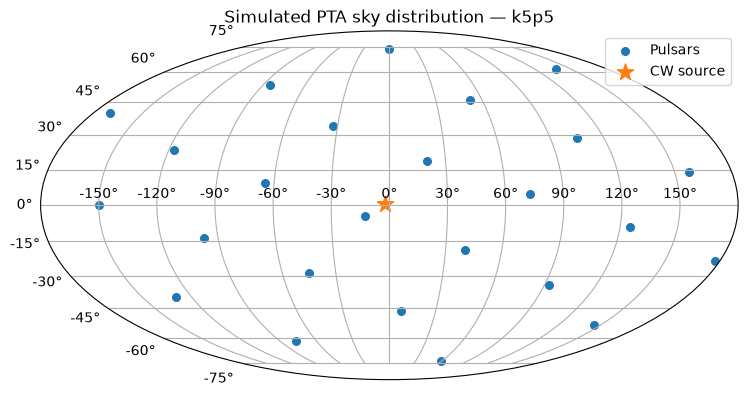

In [9]:
ra = np.array([psr.model.RAJ.quantity.to_value(u.rad) for psr in psrs])
dec = np.array([psr.model.DECJ.quantity.to_value(u.rad) for psr in psrs])
ra_wrapped = (ra + np.pi) % (2.0 * np.pi) - np.pi
source_ra_wrapped = (source_ra + np.pi) % (2.0 * np.pi) - np.pi

fig = plt.figure(figsize=(9, 5))
ax = fig.add_subplot(111, projection="mollweide")
ax.scatter(-ra_wrapped, dec, s=30, label="Pulsars")
ax.scatter(-source_ra_wrapped, source_dec, marker="*", s=150, label="CW source")
ax.grid()
ax.legend()
ax.set_title(f"Simulated PTA sky distribution — {ANALYSIS_BATCH}")
plt.show()

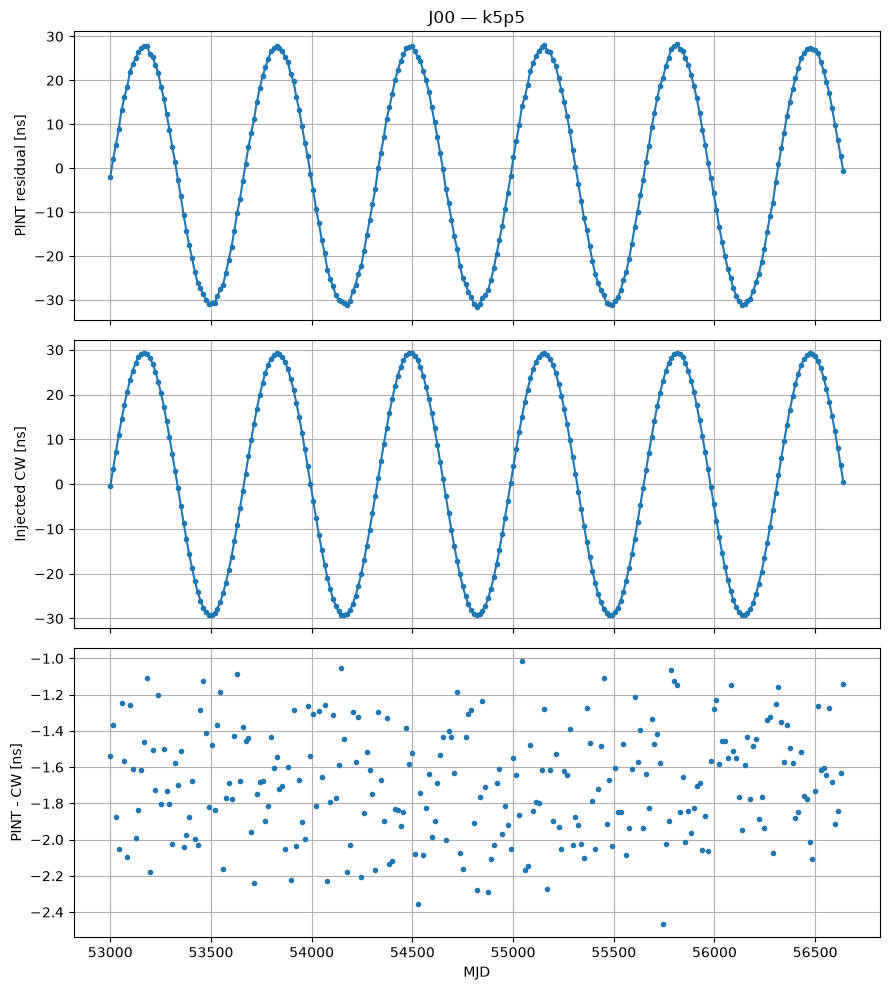

1/T [Hz]: 3.17969067969068e-09
CW frequency [Hz]: 1.748829873829874e-08
max difference [ns]: 2.4648505345225852521
RMS difference [ns]: 0.300542744582051393
relative RMS, relative max: 0.014581430936047262601 0.08411839944324928857
CW residual amplitude [ns]: 29.300337230999915


In [10]:
psr = psrs[0]
toa_mjd = psr.toas.get_mjds().value
total_residual = psr.residuals.time_resids.to_value(u.ns)
cw_residual = psr.added_signals_time[f"{psr.name}_cw"].to_value(u.ns)
difference = total_residual - cw_residual

fig, axes = plt.subplots(3, 1, figsize=(9, 10), sharex=True)
axes[0].plot(toa_mjd, total_residual, ".-")
axes[0].set_ylabel("PINT residual [ns]")
axes[0].set_title(f"{psr.name} — {ANALYSIS_BATCH}")
axes[1].plot(toa_mjd, cw_residual, ".-")
axes[1].set_ylabel("Injected CW [ns]")
axes[2].plot(toa_mjd, difference, ".")
axes[2].set_ylabel("PINT - CW [ns]")
axes[2].set_xlabel("MJD")
for ax in axes:
    ax.grid()
plt.tight_layout()
plt.show()

relative_rms = np.std(difference) / np.std(cw_residual)
relative_max = np.max(np.abs(difference)) / np.max(np.abs(cw_residual))
residual_amplitude = 0.5 * np.ptp(cw_residual)

print("1/T [Hz]:", f)
print("CW frequency [Hz]:", fgw)
print("max difference [ns]:", np.max(np.abs(difference)))
print("RMS difference [ns]:", np.std(difference))
print("relative RMS, relative max:", relative_rms, relative_max)
print("CW residual amplitude [ns]:", residual_amplitude)

In [11]:
from enterprise.pulsar import Pulsar

enterprise_psrs = [
    Pulsar(p.toas, p.model, timing_package="pint", planets=False)
    for p in psrs
]

for enterprise_psr in enterprise_psrs[:3]:
    print(
        enterprise_psr.name,
        len(enterprise_psr.toas),
        enterprise_psr.toas.min(),
        enterprise_psr.toas.max(),
    )

J00 261 4579200239.467906 4893696271.779491
J01 261 4579200104.933258 4893696069.911834
J02 261 4579200484.73054 4893696491.279551


In [12]:
final_report = {
    "archive": {
        "directory": str(legacy_archive_dir),
        "verified_files": len(archive_expected),
    },
    "ideal": {
        "directory": str(ideal_dir),
        "status": ideal_status,
        "par_files": len(list(ideal_dir.glob("*.par"))),
        "tim_files": len(list(ideal_dir.glob("*.tim"))),
        "manifest_sha256": ideal_manifest_sha256,
        "residual_stats": residual_stats(ideal_psrs),
    },
    "cw_batches": batch_reports,
    "analysis_batch": ANALYSIS_BATCH,
    "ideal_unchanged_after_injection": True,
}
assert final_report["ideal"]["par_files"] == N_PSR
assert final_report["ideal"]["tim_files"] == N_PSR
print(json.dumps(final_report, indent=2, sort_keys=True))

{
  "analysis_batch": "k5p5",
  "archive": {
    "directory": "cw_batch_data/archive/cw_partim.pre-repair-20260722T015354",
    "verified_files": 50
  },
  "cw_batches": {
    "k5p5": {
      "directory": "cw_batch_data/cw/k5p5_f1.748829873830e-08Hz",
      "fgw_hz": 1.748829873829874e-08,
      "manifest_sha256": "7e3db8f0a64f7267e8b0e0b4718bf1c5baede35b8c8af0ad1693d8f7436ee879",
      "residual_stats": {
        "max_abs_ns": 42.02828473989745,
        "rms_ns": 16.54800048715932,
        "sample_count": 6525
      },
      "status": "reused"
    }
  },
  "ideal": {
    "directory": "cw_batch_data/ideal/baseline_v1",
    "manifest_sha256": "75885e3e820bc1805716dd726e40b6e565cf334ad1f8fc03aa8efd1a5f6ad552",
    "par_files": 25,
    "residual_stats": {
      "max_abs_ns": 0.7952804793490593,
      "rms_ns": 0.3134354344553379,
      "sample_count": 6525
    },
    "status": "reused",
    "tim_files": 25
  },
  "ideal_unchanged_after_injection": true
}
